I start by importing the packages that i need.

In [ ]:
import numpy as np
import json
import sklearn
import torch
import torchaudio
import torch.nn.functional as F
from torch.utils.data import Dataset
import os
import glob
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
!pip install opendatasets
import opendatasets as od
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_predict
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization
from keras.optimizers import Adam

And i download the dataset from Kaggle.

In [ ]:
dataset_url = 'https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification/data'
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: tommasomarchetti4
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification


100%|██████████| 1.21G/1.21G [00:07<00:00, 175MB/s]


The following is a code that i found on Kaggle. Is used to turn a .wav file into a spectrogram in order for the model to be trained in image recognition.
It starts by importing the dataset and setting the parameter of the spectrogram trough torchaudio. The most important thing is that with the chosen parameters the spectogram shows only a 3 seconds audio. For that reason if the sound file in the dataset is longer then 3 seconds, the code cuts a clip of that lenght from the song starting from a random position, if instead is shorter it extends its duration. Also if the argument "augment" is set to true, it adds some monochromatic bands to the spectrogram in random positions. This is useful to avoid overfitting, as without them the model would just memorize the images. The code then returns the spectrogram and the associated label.

In [ ]:
class GTZANDataset(Dataset):
  def __init__(self, file_paths, labels, segment_len=66150, augment=False):
    self.file_paths = file_paths
    self.labels = labels
    self.segment_len = segment_len
    self.augment = augment
    self.mel_spectrogram = torchaudio.transforms.MelSpectrogram(sample_rate=22050, n_fft=2048, hop_length=512, n_mels=128)
    self.amplitude_to_db = torchaudio.transforms.AmplitudeToDB()
    self.freq_masking = torchaudio.transforms.FrequencyMasking(freq_mask_param=15)
    self.time_masking = torchaudio.transforms.TimeMasking(time_mask_param=20)

  def __len__(self):
    return len(self.file_paths)

  def __getitem__(self, idx):
    waveform, sr = torchaudio.load(self.file_paths[idx])

    if waveform.shape[0] > 1:
      waveform = torch.mean(waveform, dim=0, keepdim=True)

    if sr != 22050:
      resampler = torchaudio.transforms.Resample(sr, 22050)
      waveform = resampler(waveform)

    if waveform.shape[1] > self.segment_len:
      max_start = waveform.shape[1] - self.segment_len
      start = torch.randint(0, max_start, (1,)).item()
      waveform = waveform[:, start:start+self.segment_len]
    elif waveform.shape[1] < self.segment_len:
      pad_amount = self.segment_len - waveform.shape[1]
      waveform = F.pad(waveform, (0, pad_amount))

    mel_spec = self.mel_spectrogram(waveform)
    mel_spec = self.amplitude_to_db(mel_spec)

    if self.augment:
      mel_spec = self.freq_masking(mel_spec)
      mel_spec = self.time_masking(mel_spec)

    label = torch.tensor(self.labels[idx], dtype=torch.long)
    return mel_spec, label

This code instead is used to actually turn the spectrogram into an image.

In [ ]:
def plot_audio_features(dataset, idx=0):
  mel_spec, label = dataset[idx]
  mel_spec_np = mel_spec.squeeze(0).numpy()
  return mel_spec_np, label

This code instead creates the actual arrays for the training, validation and testing. It first separates the dataset downloaded from Kaggle in three subsets using the train_test_split method of sklearn (I also specify that the line "if f != "gtzan-dataset-music-genre-classification/Data/genres_original/jazz/jazz.00054.wav":" is used to exclude that file from the model as it is corrupted and would crash the program). I then create six empty arrays for the images and labels for the train, validation and testing. I fill them with various loops. The train is filled in a loop of 20 instances, calling the GTZANDataset function every time so to use every sound file more times. The .wav included in the datasets are in fact 30 seconds long, while the spectrograms are 3 seconds long, therefore i can use every file more than once, especially with the "augment" parameter set to true, which put more variability in the images. Subsequently, i filled the validation and test sets with a loop of 3 instances as they don't need to be too big, also the "augment" argument is here set to false as the testing needs to be done on a clean image.

In [ ]:
genre_mapping = {"disco": 0, "metal": 1, "reggae": 2, "blues": 3, "rock": 4, "classical": 5, "jazz": 6, "hiphop": 7, "country": 8, "pop": 9}

dataset_path = "gtzan-dataset-music-genre-classification/Data/genres_original"
file_paths = []
labels = []

for genre_name, genre_idx in genre_mapping.items():
  genre_folder = os.path.join(dataset_path, genre_name)
  wav_files = glob.glob(os.path.join(genre_folder, "*.wav"))
  for f in wav_files:
    if f != "gtzan-dataset-music-genre-classification/Data/genres_original/jazz/jazz.00054.wav":
      file_paths.append(f)
      labels.append(genre_idx)

train_files, test_files, train_labels, test_labels = train_test_split(file_paths, labels, test_size=0.2, random_state=42, stratify=labels)
train_files, val_files, train_labels, val_labels = train_test_split(train_files, train_labels, test_size=0.2, random_state=42, stratify=train_labels)

X_train = []
y_train = []
X_val = []
y_val = []
X_test = []
y_test = []
for i in range(0, 19):
  train_dataset = GTZANDataset(train_files, train_labels, augment=True)
  for j in range(0,len(train_files)):
    image, label = plot_audio_features(train_dataset, idx=j)
    X_train.append(image)
    y_train.append(label)
for i in range(0, 2):
  val_dataset = GTZANDataset(val_files, val_labels, augment=False)
  test_dataset = GTZANDataset(test_files, test_labels, augment=False)
  for j in range(0,len(val_files)):
    image, label = plot_audio_features(val_dataset, idx=j)
    X_val.append(image)
    y_val.append(label)
  for j in range(0,len(test_files)):
    image, label = plot_audio_features(test_dataset, idx=j)
    X_test.append(image)
    y_test.append(label)

Here i modify the array to put them in a format readable by the model.

In [ ]:
X_train = np.array(X_train).astype('float32')
min = X_train.min()
max = X_train.max()
X_train = (X_train - min) / (max - min + 1e-5)
X_train = np.array(X_train).reshape(-1, 128, 130, 1)
X_val = np.array(X_val).astype('float32')
X_val = (X_val - min) / (max - min + 1e-5)
X_val = np.array(X_val).reshape(-1, 128, 130, 1)
X_test = np.array(X_test).astype('float32')
X_test = (X_test - min) / (max - min + 1e-5)
X_test = np.array(X_test).reshape(-1, 128, 130, 1)
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)
y_train_OHE = to_categorical(y_train)
y_val_OHE = to_categorical(y_val)
y_test_OHE = to_categorical(y_test)

The model is built in the following way. The scheme has been chosen by looking at some example codes on kaggle, then modified to obtain the higher test accuracy during the training. Really important are the "Dropout" layers that avoid overfitting.

In [ ]:
model = Sequential()
model.add(Conv2D(64, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.1))
model.add(Conv2D(128, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.1))
model.add(Conv2D(256, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.1))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(10, activation='softmax'))
model.compile(optimizer=Adam(learning_rate=0.0001, clipvalue=0.1), loss='categorical_crossentropy', metrics=['accuracy'])

The training gives as result a "test accuracy" of around 0.7, which is not too high, but is the best i could get, probably also due to the intrinsic difficulty and subjectivity in the assigning of music genres.

In [ ]:
history = model.fit(X_train, y_train_OHE, epochs=30, batch_size=64, validation_data=(X_val, y_val_OHE))
test_loss, test_accuracy = model.evaluate(X_test, y_test_OHE)
print("Test accuracy:", test_accuracy)

Epoch 1/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 32s 120ms/step - accuracy: 0.3882 - loss: 1.7541 - val_accuracy: 0.1000 - val_loss: 26.9388
Epoch 2/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - accuracy: 0.5472 - loss: 1.3123 - val_accuracy: 0.1000 - val_loss: 13.9002
Epoch 3/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - accuracy: 0.6236 - loss: 1.0871 - val_accuracy: 0.1969 - val_loss: 8.5924
Epoch 4/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - accuracy: 0.6891 - loss: 0.8949 - val_accuracy: 0.4781 - val_loss: 2.3126
Epoch 5/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.7359 - loss: 0.7573 - val_accuracy: 0.4938 - val_loss: 2.4620
Epoch 6/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - accuracy: 0.7744 - loss: 0.6436 - val_accuracy: 0.5219 - val_loss: 2.6338
Epoch 7/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - accuracy: 0.8153 - loss: 0.5315 - val_accuracy: 0.6219 - val_loss: 1.7880
Epoch 8/30
190/190 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - accuracy: 0.8361 - loss: 0.4702

The dataframe of the history is shown in the plot below. The image shows how the model has actually some overfitting, has shown by the irregular "val_loss" curve.

<Axes: >

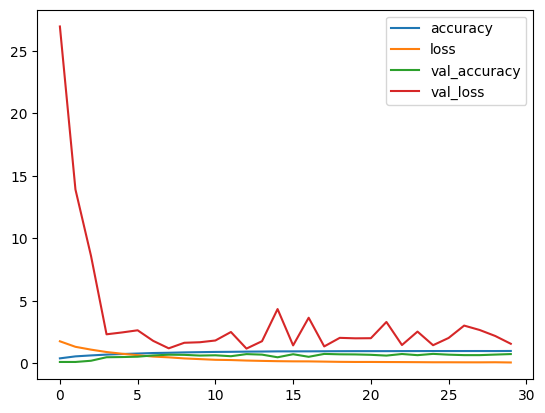

In [ ]:
pd.DataFrame(history.history).plot()

The confusion matrix however shows a good capacity of the model to predict the genres, with little deviation from the correct label.

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
[[25  5  1  0  4  1  1  0  2  1]
 [ 1 34  0  0  1  0  0  3  1  0]
 [ 5  0 26  4  0  1  0  0  2  2]
 [ 1  3  0 30  1  0  5  0  0  0]
 [ 0  8  0  6 22  2  1  0  1  0]
 [ 0  0  0  0  1 36  3  0  0  0]
 [ 0  0  0  1  2  2 33  0  2  0]
 [ 1  1  3  0  1  0  1 28  1  4]
 [ 1  0  0  0  4  2  4  1 27  1]
 [ 0  0  0  0  1  1  5  1  3 29]]


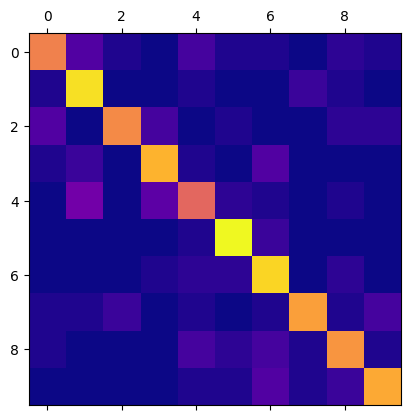

In [ ]:
confusion = confusion_matrix(y_test, np.argmax(model.predict(X_test),axis=1))
print(confusion)
plt.matshow(confusion, cmap=plt.cm.plasma)

"disco": 0, "metal": 1, "reggae": 2, "blues": 3, "rock": 4,
"classical": 5, "jazz": 6, "hiphop": 7, "country": 8, "pop": 9

The following code is used to save the model and the parameters to be used in the prediction of a new file.

In [ ]:
model.save("genre_prediction.keras")

config = {"min": float(min), "max": float(max), "genre_mapping": genre_mapping}

with open("config_model.json", "w") as f:
    json.dump(config, f, indent=4)